In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages: Annotated[list, add_messages]  

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()


True

In [11]:
from langchain_groq import ChatGroq # WAY 1 to import the ChatGroq model from the langchain_groq package. This is a specialized chat model that leverages Groq's capabilities for conversational AI tasks.
from langchain.chat_models import init_chat_model # WAY 2 to import the init_chat_model function from the langchain.chat_models module. This function is a more general approach to initializing chat models, allowing for flexibility in choosing different model backends, including Groq.

llm = init_chat_model(
    "groq:llama-3.3-70b-versatile",
    )
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.0', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000022B72F05D10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000022B72F06990>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [12]:
### Creating node definition or node functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [13]:
# creating a graph using GRAPH API
graph_builder=StateGraph(State)

# adding node
graph_builder.add_node("llmchatbot",chatbot)

# adding edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

# compile the graph
graph=graph_builder.compile()


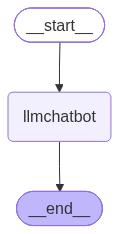

In [14]:
# visualize the graph
from IPython.display import display,Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization failed:", e)


In [15]:
response=graph.invoke({"messages":"hi"})


In [16]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

### Chatbot with Tools


In [17]:
from langchain_tavily import TavilySearch # WAY 1 to import the TavilySearch model from the langchain_tavily package. This is a specialized search model that leverages Tavily's capabilities for information retrieval tasks.

tool=TavilySearch(max_results=2)
tool.invoke("What is the capital of France?")


{'query': 'What is the capital of France?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://en.wikipedia.org/wiki/List_of_capitals_of_France',
   'title': 'List of capitals of France - Wikipedia',
   'content': 'This is a chronological list of capitals of France. The capital of France has been Paris since its liberation in 1944.\n\n## Chronology\n\n[edit] [...] Tours (10–13 June 1940), the city served as the temporary capital of France during World War II after the government fled Paris due to the German advance.\n Bordeaux (June 1940), the government was relocated from Paris to Tours then Bordeaux very briefly during World War II, when it became apparent that Paris would soon fall into German hands. [...] Paris (1789–1871), on 5 and 6 October 1789, a throng from Paris invaded the castle and forced the royal family to move back to Paris. The National Constituent Assembly "National Constituent Assembly (France)") followed the King to Paris soo

In [18]:
## Custom function
def multiply(a:int,b:int)->int:
    # This below statement is a docstring that describes the purpose of the function, its arguments, and its return value. It is a good practice to include docstrings in your functions to provide clarity and context for anyone reading or using the code.
    """ Multiply a and b 

    Args: 
        a (int): first number
        b (int): second number

    Returns:
        int: product of a and b
    """
     

In [19]:
tools=[tool,multiply]

In [20]:
llm_with_tool=llm.bind_tools(tools)

In [21]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.0', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000022B72F05D10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000022B72F06990>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search 

![Tool calling LLM structure](Images/tool_calling_llm_structure.png)

### Binding
It means LLM+Tools, basically helps the LLM to understand which all tools it has
What we need to understand specifically that how the LLM calls the tools, and how tools respond back to the llm

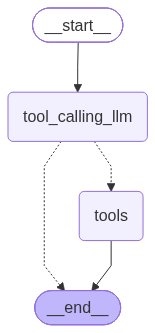

In [24]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# -------------------------------
# Define the LLM node
# -------------------------------
# This node sends the current conversation state to the LLM.
# If the LLM decides a tool is required, it returns an AIMessage
# containing one or more tool calls.
def tool_calling_llm(state: State):
    return {
        "messages": [
            llm_with_tool.invoke(state["messages"])
        ]
    }

# -------------------------------
# Create the StateGraph
# -------------------------------
builder = StateGraph(State)

# -------------------------------
# Add Nodes
# -------------------------------

# Node 1: Calls the LLM
builder.add_node("tool_calling_llm", tool_calling_llm)

# Node 2: Executes the tool(s) requested by the LLM
builder.add_node("tools", ToolNode(tools))

# -------------------------------
# Add Edges
# -------------------------------

# The graph always starts by calling the LLM
builder.add_edge(START, "tool_calling_llm")

# After the LLM responds, decide where to go next.
# - If the response contains a tool call -> route to the "tools" node.
# - Otherwise -> route directly to END.
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

# After executing the tool(s), end the workflow.
# (For multi-step agent loops, this edge would instead point back
# to the LLM node so it can process the tool's output.)
builder.add_edge("tools", END)

# -------------------------------
# Compile the graph
# -------------------------------
graph = builder.compile()

# -------------------------------
# Visualize the graph
# -------------------------------
display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
response=graph.invoke({"messages":"What is the recent stock market news for Manapurram"})

In [27]:
response['messages'][-1].content

'{"query": "Manapurram stock market news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://ca.finance.yahoo.com/quote/MANAPPURAM.NS?err_load=1", "title": "Manappuram Finance Limited (MANAPPURAM.NS) Stock Price, News, Quote & History - Yahoo Finance", "content": "Title: Manappuram Finance Limited (MANAPPURAM.NS) Stock Price, News, Quote & History - Yahoo Finance\\nSkip to navigation  Skip to right column. # Yahoo Finance. The market data on this page is currently delayed. # Manappuram Finance Limited (MANAPPURAM.NS). At close: April 30 at 3:29:58 p.m. GMT+5:30. Loading chart for MANAPPURAM.NS. * Day\'s Range  290.20 - 297.00. * Market Cap (intraday)  278.936B. * Beta (5Y Monthly)  0.63. * PE Ratio (TTM)  63.05. * Earnings Date  May 4, 2026. * Forward Dividend & Yield  2.00 (0.68%). * Ex-Dividend Date  Feb 6, 2026. Manappuram Finance Limited, a gold loan non-banking financial company, provides fund-based and fee-based financial services in India. I

In [28]:
for m in response['messages']:
    m.pretty_print()


================================ Human Message =================================

What is the recent stock market news for Manapurram
================================== Ai Message ==================================
Tool Calls:
  tavily_search (kfkz0dc8v)
 Call ID: kfkz0dc8v
  Args:
    query: Manapurram stock market news
    time_range: day
    topic: finance
================================= Tool Message =================================
Name: tavily_search

{"query": "Manapurram stock market news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://ca.finance.yahoo.com/quote/MANAPPURAM.NS?err_load=1", "title": "Manappuram Finance Limited (MANAPPURAM.NS) Stock Price, News, Quote & History - Yahoo Finance", "content": "Title: Manappuram Finance Limited (MANAPPURAM.NS) Stock Price, News, Quote & History - Yahoo Finance\nSkip to navigation  Skip to right column. # Yahoo Finance. The market data on this page is currently delayed. # Manappuram Finance L

In [30]:
response=graph.invoke({"messages":"What is 5 multiplied by 8"})
for m in response['messages']:
    m.pretty_print()


================================ Human Message =================================

What is 5 multiplied by 8
================================== Ai Message ==================================
Tool Calls:
  multiply (whact6zdp)
 Call ID: whact6zdp
  Args:
    a: 5
    b: 8
================================= Tool Message =================================
Name: multiply

null


In [31]:
response=graph.invoke({"messages":"What is the recent AI news and what is 5 multiplied by 8"})
for m in response['messages']:
    m.pretty_print()
    


================================ Human Message =================================

What is the recent AI news and what is 5 multiplied by 8
================================== Ai Message ==================================
Tool Calls:
  tavily_search (m8ze1dn2j)
 Call ID: m8ze1dn2j
  Args:
    query: recent AI news
    time_range: day
    topic: news
  multiply (zxq9p284m)
 Call ID: zxq9p284m
  Args:
    a: 5
    b: 8
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.nbcnews.com/tech/security/openai-anthropic-agent-rogue-cybergym-developer-likely-ai-hack-rcna590531", "title": "Creator of test at the heart of rogue AI hacks warns ‘there have likely been more’", "content": "00:0000:00\n\nDawn Song at an AI conference in San Francisco in 2024.Stuart Isett / Fortune/Shutterstock file\n\nAdd NBC News to Google\n\nBy Jared Pe

Notice carefully by seeing the above output-
We had asked 2 questions
    1. Recent AI news (tavily tool call)
    2. 5 multiplied by 2 (multiply tool call)

But our llm only called tavily and not multiply, WHY?


